[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1hIw7WI7eVKDbRxtgSt1C-PCU_rBWiZt0)
https://colab.research.google.com/drive/1hIw7WI7eVKDbRxtgSt1C-PCU_rBWiZt0

# Кредитный скоринг



### Задача - прогноз вероятности дефолта для клиентов банка

In [3]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.0 MB/s eta 0:00:00


In [4]:
# import packages
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, cross_val_score
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

sns.set_style()

import warnings
warnings.filterwarnings('ignore')

In [5]:
# Параметры визуализации matplotlib
COLOR = '#ababab'
mpl.rcParams['figure.titlesize'] = 16
mpl.rcParams['text.color'] = 'black'
mpl.rcParams['axes.labelcolor'] = COLOR
mpl.rcParams['xtick.color'] = COLOR
mpl.rcParams['ytick.color'] = COLOR
mpl.rcParams['grid.color'] = COLOR
mpl.rcParams['grid.alpha'] = 0.1

In [6]:
# ПРочитайте файл

df_credit = 

In [ ]:
# покажите первые 5 строк
df_credit

## Аналитика

Оценим объем данных и 

In [ ]:
# Покажите размер данных (число строк и столбцов)
df_credit

In [ ]:
# Покажите summary о данных
df_credit

In [ ]:
# Оцените долю пропусков по каждой фиче. Нужно/можно ли удалить какуюто из фичей?
df_credit

In [11]:
# Удалите пропуски в таргете
df_credit

In [12]:
# Удалите фичи, если необходимо
df_credit

In [ ]:
# Оцените число уникальных значений по каждой фиче
df_credit

In [14]:
# Удалите фичи, если необходимо
# df_credit

In [15]:
# Удалим часть id фичей и сложно-преобразуемые фичи
df_credit.drop(labels=['email', 'reason', 'zip', 'job_name', 'external_data_provider_first_name', 'lat_lon',
                       'shipping_zip_code', 'user_agent', 'profile_tags', 'marketing_channel',
                       'profile_phone_number', 'application_time_applied', 'ids'], axis=1, inplace=True)

In [ ]:
# Оцените, есть ли фичи с аномальными значениями
df_credit

In [19]:
# Если такие фичи есть, то замените их значения на np.nan
df_credit


In [20]:
# выборка с числовыми фичами
df_credit_numerical = df_credit[['score_3', 'risk_rate', 'last_amount_borrowed',
                                 'last_borrowed_in_months', 'credit_limit', 'income', 'ok_since',
                                 'n_bankruptcies', 'n_defaulted_loans', 'n_accounts', 'n_issues',
                                 'external_data_provider_email_seen_before']]

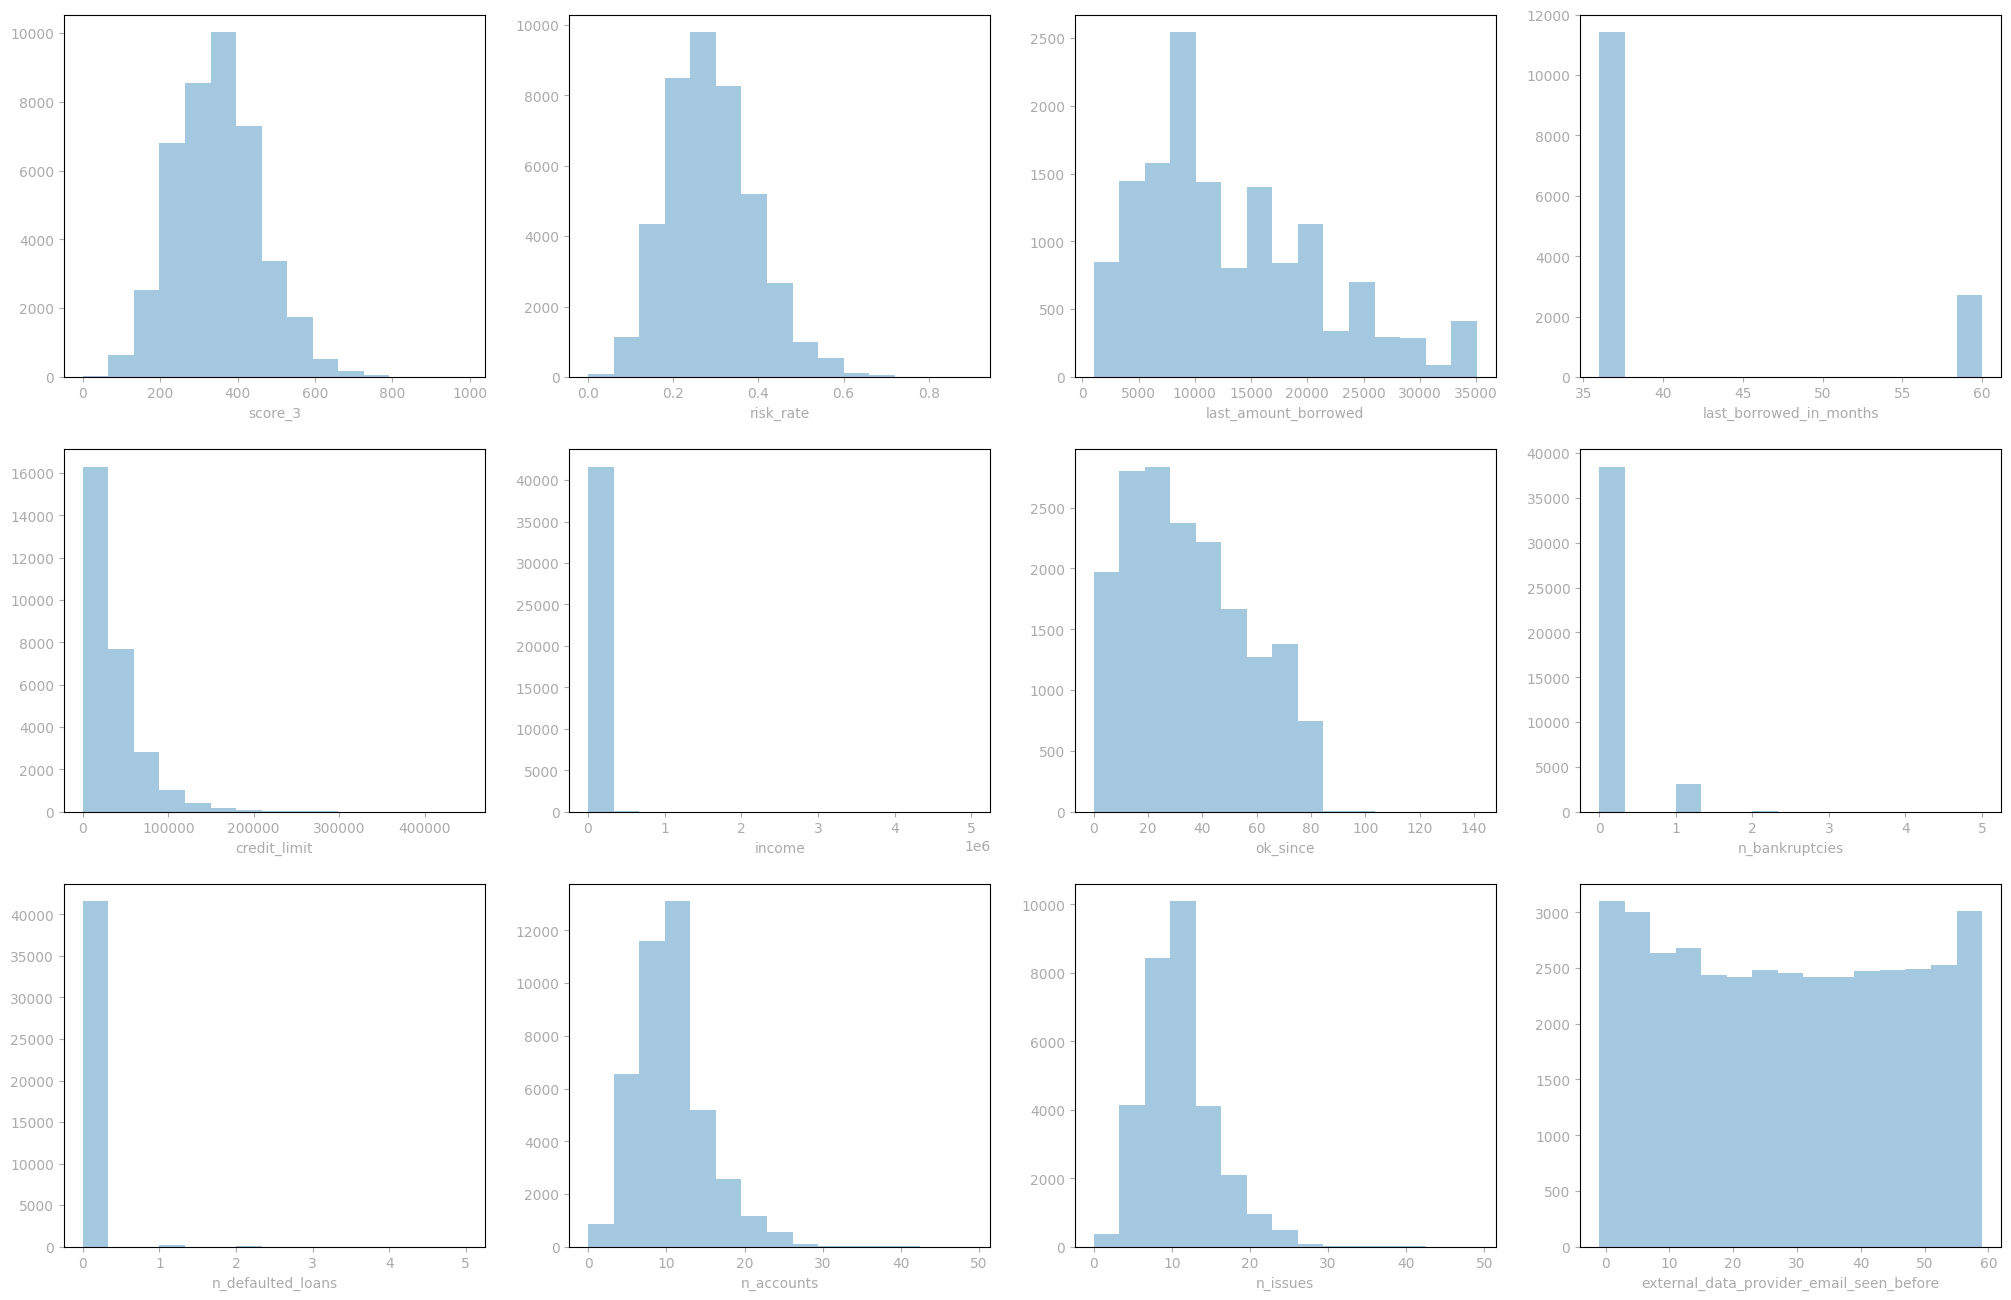

In [21]:
# отрисовка распределений

nrows = 3
ncols = 4

fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(25, 16))

r = 0
c = 0

for i in df_credit_numerical:
    sns.distplot(df_credit_numerical[i], bins=15,kde=False, ax=ax[r][c])
    if c == ncols - 1:
        r += 1
        c = 0
    else:
        c += 1

plt.show()

Какой вывод можно сделать исходя из этих графиков?

In [22]:
df_credit_num = df_credit.select_dtypes(exclude='object').columns
df_credit_cat = df_credit.select_dtypes(include='object').columns

# Заполните 0 пропуски в фичах `last_amount_borrowed`, `last_borrowed_in_months` и `n_issues`
df_credit

# заполнение числовых фичей медианой
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
imputer = imputer.fit(df_credit.loc[:, df_credit_num])
df_credit.loc[:, df_credit_num] = imputer.transform(df_credit.loc[:, df_credit_num])

# заполнение категориальных фичей медианой
imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
imputer = imputer.fit(df_credit.loc[:, df_credit_cat])
df_credit.loc[:, df_credit_cat] = imputer.transform(df_credit.loc[:, df_credit_cat])

In [23]:
df_credit.isnull().sum()

,0
target_default,0
score_1,0
score_2,0
score_3,0
score_4,0
score_5,0
score_6,0
risk_rate,0
last_amount_borrowed,0
last_borrowed_in_months,0


Перед моделированием необходимо перевести категориальные фичи в числовые

In [24]:
# Преобразование категориальных фичей
bin_var = df_credit.nunique()[df_credit.nunique() == 2].keys().tolist()
num_var = [col for col in df_credit.select_dtypes(['int', 'float']).columns.tolist() if col not in bin_var]
cat_var = [col for col in df_credit.select_dtypes(['object']).columns.tolist() if col not in bin_var]

df_credit_encoded = df_credit.copy()

le = LabelEncoder()
for col in bin_var:
    df_credit_encoded[col] = le.fit_transform(df_credit_encoded[col])

df_credit_encoded = pd.get_dummies(df_credit_encoded, columns=cat_var)

df_credit_encoded.head()

,target_default,score_3,score_4,score_5,score_6,risk_rate,last_amount_borrowed,last_borrowed_in_months,credit_limit,income,...,shipping_state_BR-PE,shipping_state_BR-PR,shipping_state_BR-RN,shipping_state_BR-RO,shipping_state_BR-RR,shipping_state_BR-RS,shipping_state_BR-SC,shipping_state_BR-SE,shipping_state_BR-SP,shipping_state_BR-TO
0,0,350.0,101.800832,0.259555,108.427273,0.40,25033.92,36.0,0.0,65014.12,...,False,False,False,False,False,False,False,False,False,False
1,0,370.0,97.062615,0.942655,92.002546,0.24,0.00,0.0,39726.0,100018.91,...,False,False,False,False,False,True,False,False,False,False
2,1,360.0,100.027073,0.351918,112.892453,0.29,7207.92,36.0,25213.0,65023.65,...,False,False,False,False,True,False,False,False,False,False
3,0,510.0,101.599485,0.987673,94.902491,0.32,0.00,0.0,54591.0,68830.01,...,False,False,True,False,False,False,False,False,False,False
4,0,500.0,98.474289,0.532539,118.126207,0.18,0.00,0.0,25213.0,60011.29,...,False,False,False,False,False,False,False,False,False,False


## ML модели

Протестируем все 3 варианты бустинга


*   XGBoost
*   LightGBM
*   CatBoost


In [25]:
# Разделим данные на train и test выборки
X = df_credit_encoded.drop('target_default', axis=1)

# target vector
y = df_credit_encoded['target_default']

X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=True, stratify=y)

In [ ]:
# Функция для кросс валидации
def val_model(X, y, clf, show=True):
    """
    Кросс валидация для обучающей ваыборки.

    # Входные параметры
        X: фичи
        y: таргет
        clf: обучаемая модель

    # Выходные параметры
        средний скор по кросс валидации.
    """

    X = np.array(X)
    y = np.array(y)

    pipeline = make_pipeline(StandardScaler(), clf)
    scores = cross_val_score(pipeline, X, y, scoring='recall')

    if show == True:
        print(f'Recall: {scores.mean()}, {scores.std()}')

    return scores.mean()

In [ ]:
# оценка качества моделей через метрику recall
xgb = XGBClassifier()
lgb = LGBMClassifier()
cb = CatBoostClassifier()

model = []
recall = []

for clf in (xgb, lgb, cb):
    model.append(clf.__class__.__name__)
    recall.append(val_model(X_train_rus, y_train_rus, clf, show=False))

pd.DataFrame(data=recall, index=model, columns=['Recall'])

A saída de streaming foi truncada nas últimas 5000 linhas.
5:	learn: 0.6766031	total: 93.4ms	remaining: 15.5s
6:	learn: 0.6744241	total: 101ms	remaining: 14.3s
7:	learn: 0.6721765	total: 108ms	remaining: 13.4s
8:	learn: 0.6702457	total: 115ms	remaining: 12.6s
9:	learn: 0.6681527	total: 122ms	remaining: 12s
10:	learn: 0.6661466	total: 129ms	remaining: 11.6s
11:	learn: 0.6643063	total: 136ms	remaining: 11.2s
12:	learn: 0.6625519	total: 143ms	remaining: 10.9s
13:	learn: 0.6608213	total: 150ms	remaining: 10.6s
14:	learn: 0.6593619	total: 157ms	remaining: 10.3s
15:	learn: 0.6577092	total: 164ms	remaining: 10.1s
16:	learn: 0.6562553	total: 171ms	remaining: 9.9s
17:	learn: 0.6550841	total: 178ms	remaining: 9.72s
18:	learn: 0.6538765	total: 185ms	remaining: 9.57s
19:	learn: 0.6527047	total: 194ms	remaining: 9.52s
20:	learn: 0.6513253	total: 204ms	remaining: 9.51s
21:	learn: 0.6501324	total: 211ms	remaining: 9.38s
22:	learn: 0.6489885	total: 218ms	remaining: 9.27s
23:	learn: 0.6479283	total: 22

,Recall
XGBClassifier,0.662726
LGBMClassifier,0.647915
CatBoostClassifier,0.645911


              precision    recall  f1-score   support

           0       0.92      0.44      0.60      8771
           1       0.22      0.81      0.34      1665

    accuracy                           0.50     10436
   macro avg       0.57      0.63      0.47     10436
weighted avg       0.81      0.50      0.56     10436



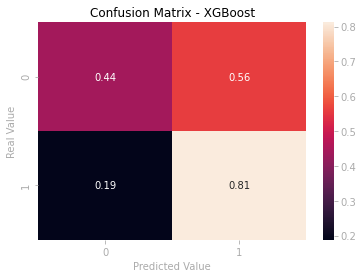

In [ ]:
# обучение модели
xgb = XGBClassifier(max_depth=3, learning_rate=0.0001, n_estimators=50, gamma=1, min_child_weight=6)
xgb.fit(X_train_rus, y_train_rus)

# прогнозирование
X_test_xgb = scaler.transform(X_test)
y_pred_xgb = xgb.predict(X_test_xgb)

# отчет о модели
print(classification_report(y_test, y_pred_xgb))

# confusion матрица
fig, ax = plt.subplots()
sns.heatmap(confusion_matrix(y_test, y_pred_xgb, normalize='true'), annot=True, ax=ax)
ax.set_title('Confusion Matrix - XGBoost')
ax.set_xlabel('Predicted Value')
ax.set_ylabel('Real Value')

plt.show()

              precision    recall  f1-score   support

           0       0.91      0.62      0.74      8771
           1       0.25      0.68      0.37      1665

    accuracy                           0.63     10436
   macro avg       0.58      0.65      0.55     10436
weighted avg       0.81      0.63      0.68     10436



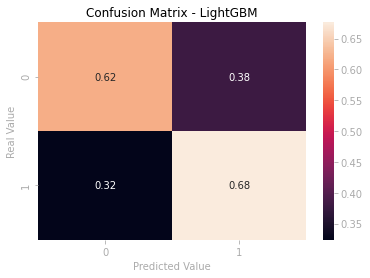

In [ ]:
# обучение модели
lgb = LGBMClassifier(num_leaves=70, max_depth=5, learning_rate=0.01, min_data_in_leaf=400)
lgb.fit(X_train_rus, y_train_rus)

# прогнозирование
X_test_lgb = scaler.transform(X_test)
y_pred_lgb = lgb.predict(X_test_lgb)

# отчет о модели
print(classification_report(y_test, y_pred_lgb))

# confusion матрица
fig, ax = plt.subplots()
sns.heatmap(confusion_matrix(y_test, y_pred_lgb, normalize='true'), annot=True, ax=ax)
ax.set_title('Confusion Matrix - LightGBM')
ax.set_xlabel('Predicted Value')
ax.set_ylabel('Real Value')

plt.show()

              precision    recall  f1-score   support

           0       0.91      0.67      0.77      8771
           1       0.27      0.64      0.38      1665

    accuracy                           0.66     10436
   macro avg       0.59      0.65      0.57     10436
weighted avg       0.81      0.66      0.71     10436



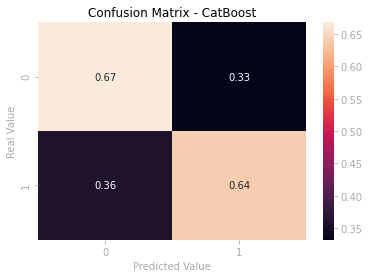

In [ ]:
# обучение модели
cb = CatBoostClassifier(learning_rate=0.03, depth=6, l2_leaf_reg=5, logging_level='Silent')
cb.fit(X_train_rus, y_train_rus)

# прогнозирование
X_test_cb = scaler.transform(X_test)
y_pred_cb = cb.predict(X_test_cb)

# отчет о модели
print(classification_report(y_test, y_pred_cb))

# confusion матрица
fig, ax = plt.subplots()
sns.heatmap(confusion_matrix(y_test, y_pred_cb, normalize='true'), annot=True, ax=ax)
ax.set_title('Confusion Matrix - CatBoost')
ax.set_xlabel('Predicted Value')
ax.set_ylabel('Real Value')

plt.show()